# Sequential ViDA: APTOS → IDRiD → APTOS (RETFound-DINOv2)

Protocol:
1. Load RETFound pretrained weights
2. Evaluate baseline on source domain (APTOS)
3. Adapt to target domain (IDRiD) - adaptation mode
4. Evaluate on ALL previous domains (APTOS, IDRiD) - TEST mode

This measures catastrophic forgetting: after adapting to IDRiD,
how much performance degrades on APTOS?

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/sequential/vida/aptos_idrid.yaml')

print('Protocol: Sequential ViDA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential ViDA
Source: aptos2019
Targets: ['idrid']
Method: cotta
Output: ./outputs/sequential_vida/aptos_idrid/
HF_TOKEN set


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-08-05 10:27:52,465 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: aptos2019 -> idrid
2026-08-05 10:27:57,026 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/YukunZhou/RETFound_dinov2_meh/resolve/main/RETFound_dinov2_meh.pth "HTTP/1.1 302 Found"
2026-08-05 10:27:57,184 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/YukunZhou/RETFound_dinov2_meh/xet-read-token/6dff4c76632983267a6ae3000f7852b1f8667d9c "HTTP/1.1 200 OK"


RETFound_dinov2_meh.pth:   0%|          | 0.00/1.61G [00:00<?, ?B/s]

2026-08-05 10:28:05,879 - src.models.retfound - INFO - Extracted state_dict from DINOv2 'teacher' key
2026-08-05 10:28:05,881 - src.models.retfound - INFO - Stripped 'backbone.' prefix from 359 state dict keys
2026-08-05 10:28:05,882 - src.models.retfound - INFO - RETFound checkpoint cached in CPU RAM
2026-08-05 10:28:06,055 - src.models.retfound - INFO - Feature normalization ENABLED in forward() (required for prototype classifier)
2026-08-05 10:28:06,748 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-05 10:30:54,217 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=100.0
2026-08-05 10:30:54,221 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 2930 training samples (5 classes, 1024-dim features, T=100.0)
2026-08-05 10:30:55,498 - src.evaluation.runner.sequential - INFO - Evaluating baseline on source domain: aptos2019
2026-08-05 10:31:19,075 - src.evaluation.runner.sequential - INFO - Baseline QWK on aptos2

Adapting to aptos2019:   0%|          | 0/23 [00:00<?, ?it/s]

2026-08-05 10:31:38,869 - src.evaluation.runner.sequential - INFO -   Adapt step 0: loss=0.0025, kl=0.0025, conf_samples=-1, teacher_max_prob=-1.0000


...

Adapting to idrid:  86%|████████▌ | 6/7 [01:40<00:16, 16.32s/it, acc=0.2500, adaptations=6]

2026-08-05 10:40:12,389 - src.evaluation.runner.sequential - INFO -   Adapt step 6: loss=0.0659, kl=0.0659, conf_samples=-1, teacher_max_prob=-1.0000


Adapting to idrid: 100%|██████████| 7/7 [01:47<00:00, 15.31s/it, acc=0.2857, adaptations=7]

2026-08-05 10:40:12,778 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on idrid


2026-08-05 10:40:23,382 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.4785
2026-08-05 10:40:23,383 - src.evaluation.runner.sequential - INFO - Adaptations: 7/7
2026-08-05 10:40:23,509 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 2 seen domains after adapting to idrid
2026-08-05 10:40:23,511 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on aptos2019 (no adaptation)
2026-08-05 10:40:49,531 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.6824
2026-08-05 10:40:59,305 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.4785
2026-08-05 10:40:59,308 - src.evaluation.runner.sequential - INFO - 
2026-08-05 10:40:59,310 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summary
2026-08-05 10:40:59,311 - src.evaluation.runner.sequential - INFO - ============================================================
2026-08-05 10:40:59,312 - src.evaluation.runner.sequential - INFO - Baseline QWK (apto

=============== Sequential CTTA Results (ViDA DINOv2) ================

Source domain: aptos2019
  Baseline QWK:           0.7318
  Baseline Overall Acc:   63.66%

Target domains: idrid

----------------------------------------------------------------------
After adapting to source aptos2019 (23/23 batches):
  QWK:                  0.7242  (delta: -0.0076)
  Overall Acc:          63.66% (delta: +0.00pp)

----------------------------------------------------------------------
After adapting to idrid (7/7 batches):
  Post-adaptation QWK on idrid: 0.4785
  Post-adaptation Acc on idrid: 23.30%
  Test on aptos2019:
    QWK: 0.6824  (delta vs baseline: -0.0495)
    Acc: 54.10% (delta vs baseline: -9.56pp)



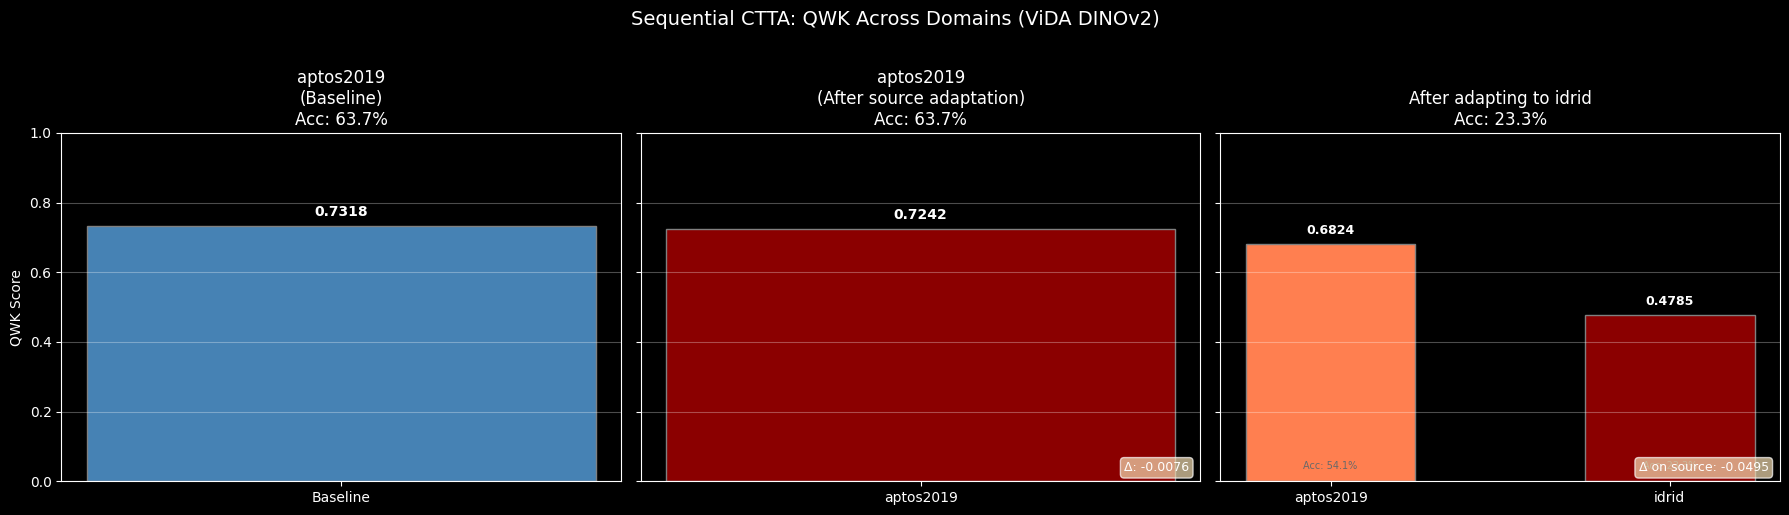

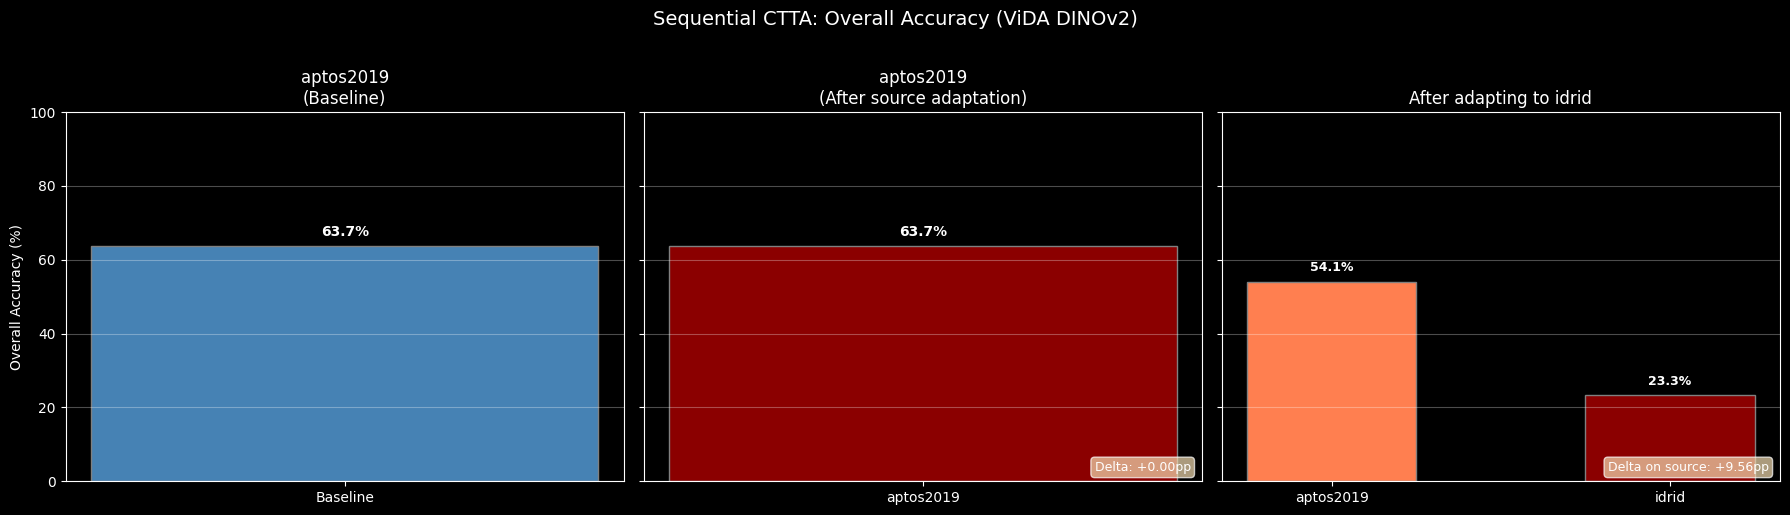

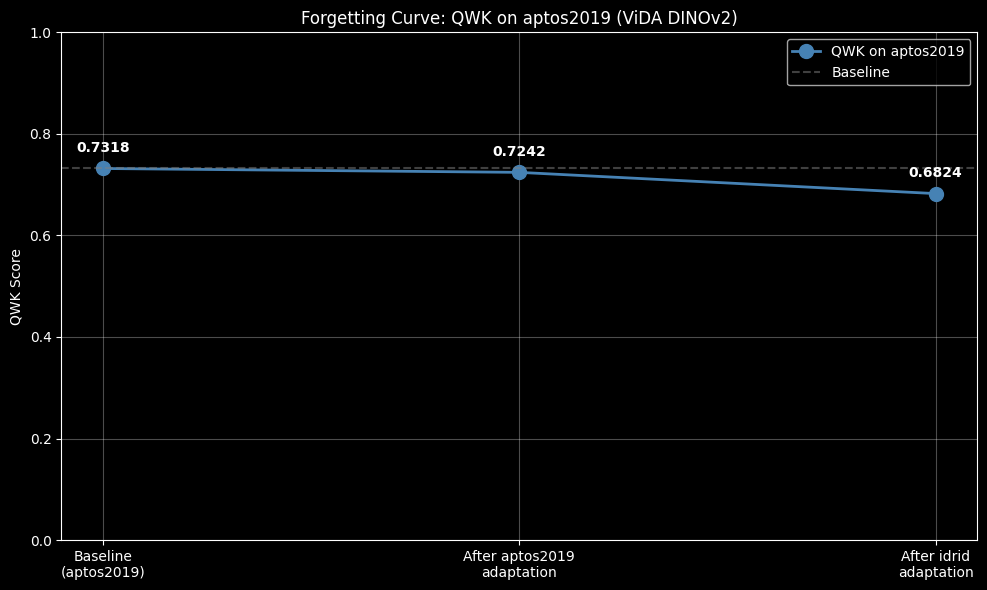

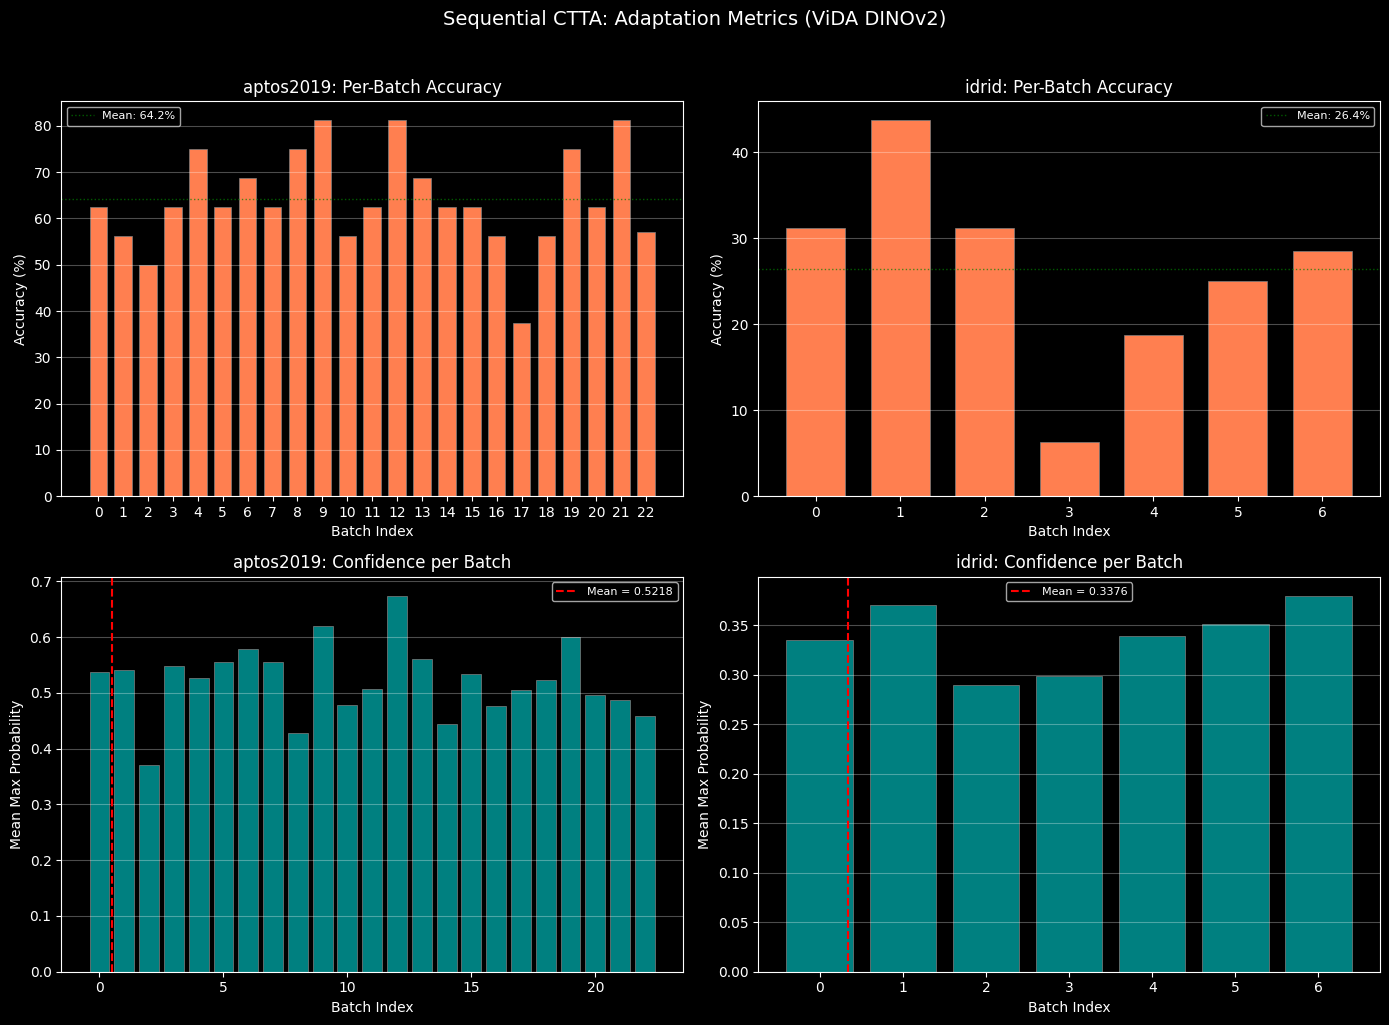

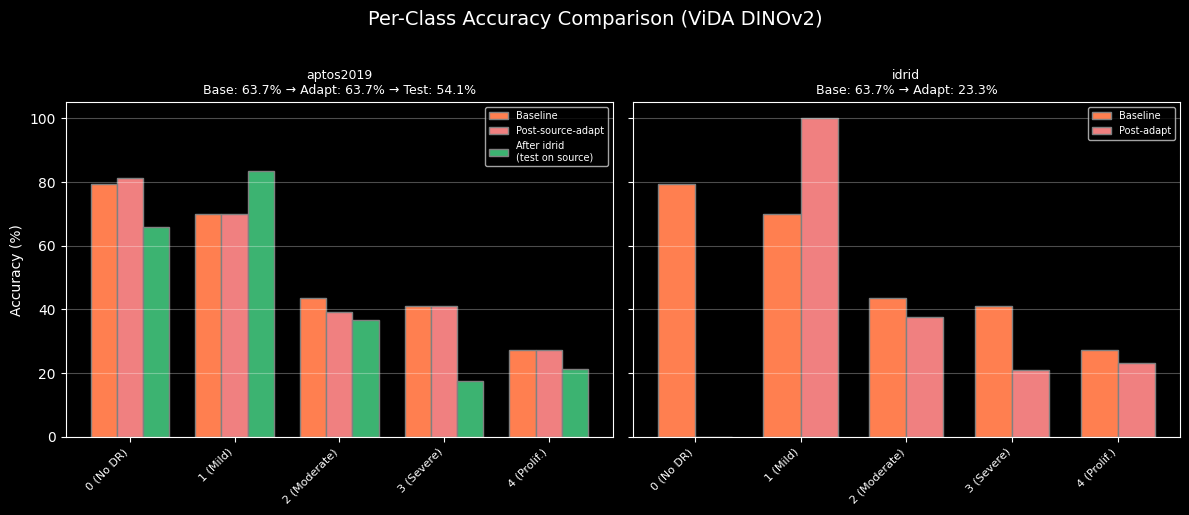

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

print_sequential_summary(results, method_name='ViDA DINOv2')
plot_sequential_qwk_comparison(results, plots_dir, method_name='ViDA DINOv2')
plot_sequential_overall_accuracy(results, plots_dir, method_name='ViDA DINOv2')
plot_sequential_forgetting(results, plots_dir, method_name='ViDA DINOv2')
plot_sequential_adaptation_comparison(results, plots_dir, method_name='ViDA DINOv2')
plot_sequential_per_class_accuracy(results, plots_dir, method_name='ViDA DINOv2')